In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (7, 5)

Matplotlib is building the font cache; this may take a moment.


In [3]:
PROJECT_ROOT = Path.cwd().parent

csv_path = PROJECT_ROOT / "evaluation" / "evaluation_csv.csv"

df = pd.read_csv(csv_path)

print(f"Total Questions Evaluated : {len(df)}")

df.head()

Total Questions Evaluated : 147


,Question,Ground Truth Answer,LLM Generated Answer,Document Retrieval Score,Faithfulness Score
0,What is the short title of the continuing appr...,"The short title of the act is the ""Continuing ...","Continuing Appropriations Act, 2024 and Other ...",YES,YES
1,"Under Section 106, on what date does the conti...",The continuing appropriations authority expire...,The supplied documents do not contain the expi...,NO,NO
2,What is the name of the Act that establishes a...,"The Act is the ""Good Samaritan Remediation of ...",Good Samaritan Remediation of Abandoned Hardro...,YES,YES
3,"According to the Good Samaritan Act, what is a...",The site must be one for which the Administrat...,An abandoned hardrock mine site must be one fo...,YES,YES
4,"Under the Good Samaritan Act, what is the maxi...",The Administrator may grant not more than 15 G...,The Act does not set a statutory cap on the nu...,NO,NO


In [4]:
df["Document Retrieval Score"] = (
    df["Document Retrieval Score"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["Faithfulness Score"] = (
    df["Faithfulness Score"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [5]:
total = len(df)

retrieval_yes = (df["Document Retrieval Score"] == "YES").sum()
retrieval_no = total - retrieval_yes

faithfulness_yes = (df["Faithfulness Score"] == "YES").sum()
faithfulness_no = total - faithfulness_yes


reference_retrieval_accuracy = (
    retrieval_yes / total
) * 100

faithfulness = (
    faithfulness_yes / total
) * 100


overall_reliable = (
    (
        (df["Document Retrieval Score"] == "YES")
        &
        (df["Faithfulness Score"] == "YES")
    ).sum()
)

overall_reliability = (
    overall_reliable / total
) * 100


hallucination_rate = (
    faithfulness_no / total
) * 100


citation_error_rate = (
    retrieval_no / total
) * 100


retrieval_only_failures = (
    (
        (df["Document Retrieval Score"] == "NO")
        &
        (df["Faithfulness Score"] == "YES")
    ).sum()
)

faithfulness_only_failures = (
    (
        (df["Document Retrieval Score"] == "YES")
        &
        (df["Faithfulness Score"] == "NO")
    ).sum()
)

complete_failures = (
    (
        (df["Document Retrieval Score"] == "NO")
        &
        (df["Faithfulness Score"] == "NO")
    ).sum()
)

In [6]:
print("="*70)

print(f"Total Questions Evaluated        : {total}")

print("="*70)

print(f"Reference Retrieval Accuracy     : {reference_retrieval_accuracy:.2f}%")

print(f"Faithfulness                    : {faithfulness:.2f}%")

print(f"Overall Reliability             : {overall_reliability:.2f}%")

print(f"Hallucination Rate              : {hallucination_rate:.2f}%")

print(f"Citation Error Rate             : {citation_error_rate:.2f}%")

print("="*70)

print(f"Retrieval-only Failures         : {retrieval_only_failures}")

print(f"Faithfulness-only Failures      : {faithfulness_only_failures}")

print(f"Complete Failures               : {complete_failures}")

print("="*70)

Total Questions Evaluated        : 147
Reference Retrieval Accuracy     : 54.42%
Faithfulness                    : 67.35%
Overall Reliability             : 46.94%
Hallucination Rate              : 32.65%
Citation Error Rate             : 45.58%
Retrieval-only Failures         : 30
Faithfulness-only Failures      : 11
Complete Failures               : 37


In [7]:
summary = pd.DataFrame({

    "Metric":[

        "Reference Retrieval Accuracy",

        "Faithfulness",

        "Overall Reliability",

        "Hallucination Rate",

        "Citation Error Rate"

    ],

    "Score (%)":[

        round(reference_retrieval_accuracy,2),

        round(faithfulness,2),

        round(overall_reliability,2),

        round(hallucination_rate,2),

        round(citation_error_rate,2)

    ]

})

summary

,Metric,Score (%)
0,Reference Retrieval Accuracy,54.42
1,Faithfulness,67.35
2,Overall Reliability,46.94
3,Hallucination Rate,32.65
4,Citation Error Rate,45.58


In [8]:
summary = pd.DataFrame({

    "Metric":[

        "Reference Retrieval Accuracy",

        "Faithfulness",

        "Overall Reliability",

        "Hallucination Rate",

        "Citation Error Rate"

    ],

    "Score (%)":[

        round(reference_retrieval_accuracy,2),

        round(faithfulness,2),

        round(overall_reliability,2),

        round(hallucination_rate,2),

        round(citation_error_rate,2)

    ]

})

summary

,Metric,Score (%)
0,Reference Retrieval Accuracy,54.42
1,Faithfulness,67.35
2,Overall Reliability,46.94
3,Hallucination Rate,32.65
4,Citation Error Rate,45.58


In [9]:
joint_table = pd.crosstab(

    df["Document Retrieval Score"],

    df["Faithfulness Score"],

    margins=True

)

joint_table

Faithfulness Score,NO,YES,All
Document Retrieval Score,,,
NO,37,30,67
YES,11,69,80
All,48,99,147


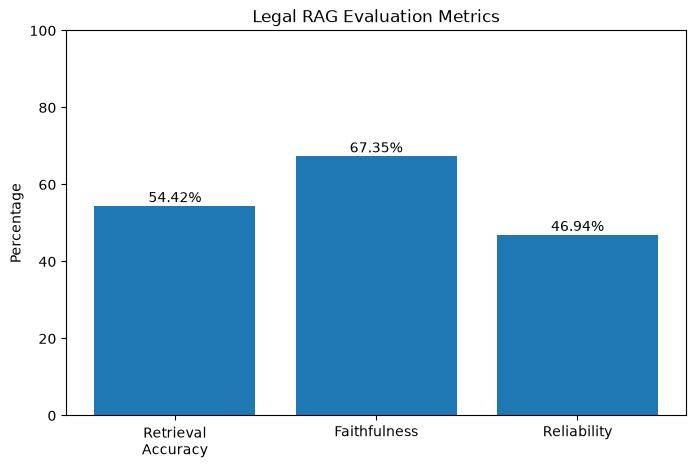

In [10]:
plt.figure(figsize=(8,5))

metrics = [

    "Retrieval\nAccuracy",

    "Faithfulness",

    "Reliability"

]

scores = [

    reference_retrieval_accuracy,

    faithfulness,

    overall_reliability

]

bars = plt.bar(metrics, scores)

plt.ylim(0,100)

plt.ylabel("Percentage")

plt.title("Legal RAG Evaluation Metrics")

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+1,

        f"{bar.get_height():.2f}%",

        ha="center"

    )

plt.show()

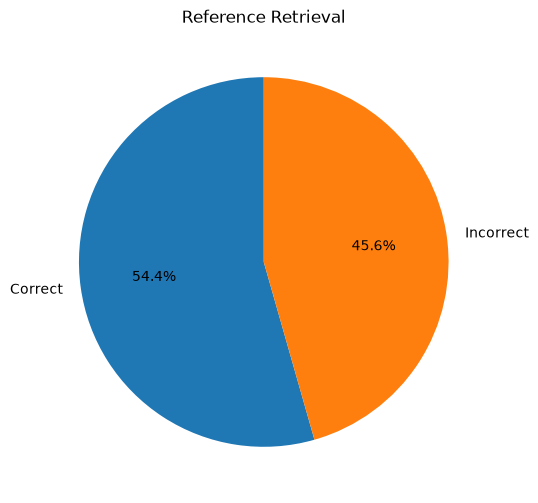

In [12]:
plt.figure(figsize=(6,6))

plt.pie(

    [retrieval_yes,retrieval_no],

    labels=[

        "Correct",

        "Incorrect"

    ],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Reference Retrieval")

plt.show()

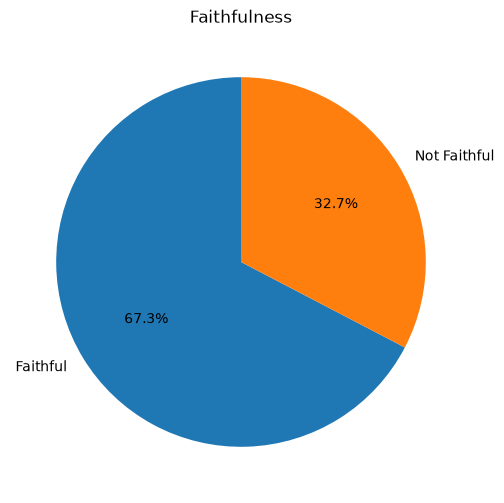

In [13]:
plt.figure(figsize=(6,6))

plt.pie(

    [faithfulness_yes,faithfulness_no],

    labels=[

        "Faithful",

        "Not Faithful"

    ],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Faithfulness")

plt.show()

In [14]:
failure_df = pd.DataFrame({

    "Failure Type":[

        "Retrieval Only",

        "Faithfulness Only",

        "Both Failed"

    ],

    "Count":[

        retrieval_only_failures,

        faithfulness_only_failures,

        complete_failures

    ]

})

failure_df

,Failure Type,Count
0,Retrieval Only,30
1,Faithfulness Only,11
2,Both Failed,37


In [15]:
report_path = PROJECT_ROOT / "evaluation" / "evaluation_report.csv"

summary.to_csv(

    report_path,

    index=False

)

print("Saved Evaluation Report")

print(report_path)

Saved Evaluation Report
d:\Projects\legal-rag-system\evaluation\evaluation_report.csv
